<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/HW_5_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота № 5

Манзар Л.В


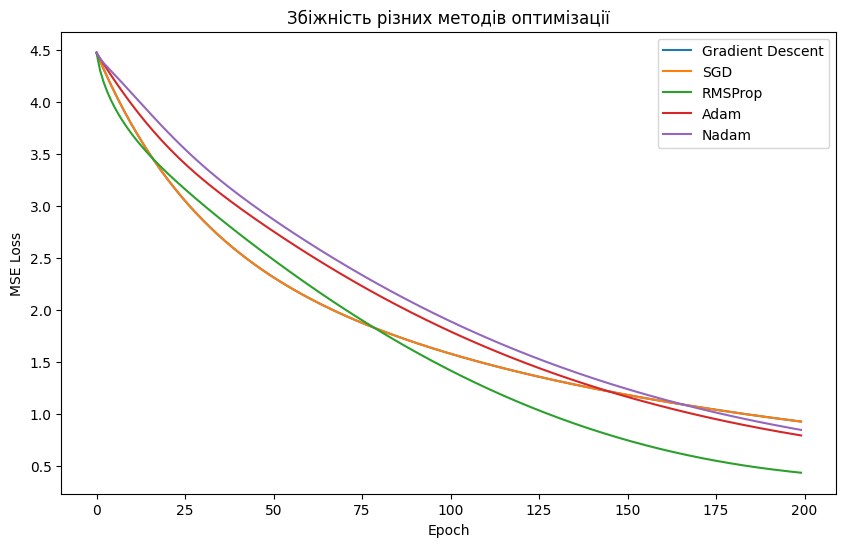

              Метод  Середній час (сек)
0  Gradient Descent            0.021129
1               SGD            2.589255
2           RMSProp            3.251322
3              Adam            4.359481
4             Nadam            7.313286


In [ ]:
# === Імпорт бібліотек ===
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Nadam
from sklearn.preprocessing import PolynomialFeatures
import timeit
import pandas as pd

# === 1. Генерація даних ===
np.random.seed(42)
X = np.random.rand(100, 2)
x1, x2 = X[:,0], X[:,1]

def polynomial(x1, x2):
    return 4*x1**2 + 5*x2**2 - 2*x1*x2 + 3*x1 - 6*x2

y = polynomial(x1, x2)

# Додаткові ознаки
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# === 2. Допоміжні функції ===
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def predict(X, w):
    return X @ w

# === 3. Gradient Descent вручну ===
def train_gd(X, y, lr=0.01, epochs=200):
    w = np.zeros(X.shape[1])
    losses = []
    for epoch in range(epochs):
        y_pred = predict(X, w)
        grad = -2/X.shape[0] * X.T @ (y - y_pred)
        w -= lr * grad
        losses.append(mse_loss(y, y_pred))
    return losses

# === 4. Тренування з keras-оптимізаторами ===
def train_optimizer(optimizer, X, y, epochs=200):
    w = tf.Variable(tf.zeros((X.shape[1],1), dtype=tf.float32))
    losses = []
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            y_pred = tf.matmul(X.astype(np.float32), w)
            loss = tf.reduce_mean((y.reshape(-1,1).astype(np.float32) - y_pred)**2)
        grad = tape.gradient(loss, [w])
        optimizer.apply_gradients(zip(grad, [w]))
        losses.append(loss.numpy())
    return losses

# === 5. Запуск для всіх методів ===
losses_dict = {}
losses_dict["Gradient Descent"] = train_gd(X_poly, y, lr=0.01, epochs=200)

optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "RMSProp": RMSprop(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.01),
    "Nadam": Nadam(learning_rate=0.01)
}

for name, opt in optimizers.items():
    losses_dict[name] = train_optimizer(opt, X_poly, y, epochs=200)

# === 6. Візуалізація втрат ===
plt.figure(figsize=(10,6))
for name, losses in losses_dict.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Збіжність різних методів оптимізації")
plt.legend()
plt.show()

# === 7. Вимірювання часу ===
gd_time = timeit.timeit(lambda: train_gd(X_poly, y, lr=0.01, epochs=200), number=3)
sgd_time = timeit.timeit(lambda: train_optimizer(SGD(learning_rate=0.01), X_poly, y, epochs=200), number=3)
rmsprop_time = timeit.timeit(lambda: train_optimizer(RMSprop(learning_rate=0.01), X_poly, y, epochs=200), number=3)
adam_time = timeit.timeit(lambda: train_optimizer(Adam(learning_rate=0.01), X_poly, y, epochs=200), number=3)
nadam_time = timeit.timeit(lambda: train_optimizer(Nadam(learning_rate=0.01), X_poly, y, epochs=200), number=3)

results = pd.DataFrame({
    "Метод": ["Gradient Descent", "SGD", "RMSProp", "Adam", "Nadam"],
    "Середній час (сек)": [gd_time, sgd_time, rmsprop_time, adam_time, nadam_time]
})

print(results)


# Підбір оптимальної кількості ітерацій

In [3]:
epochs_list = [50, 100, 200, 500]

for ep in epochs_list:
    opt = Adam(learning_rate=0.01)   # створюємо новий оптимізатор щоразу
    losses = train_optimizer(opt, X_poly, y, epochs=ep)
    print(f"Epochs={ep}, Final Loss={losses[-1]}")


Epochs=50, Final Loss=2.777756929397583
Epochs=100, Final Loss=1.8094372749328613
Epochs=200, Final Loss=0.7950204610824585
Epochs=500, Final Loss=0.31594300270080566


## Висновки

У ході виконання завдання було реалізовано та протестовано кілька варіантів методу градієнтного спуску: **Gradient Descent, SGD, RMSProp, Adam, Nadam**.  

### Основні результати:
- **Gradient Descent** — простий у реалізації, швидкий на крок, але потребує більше епох (~500), щоб досягти низьких втрат.  
- **SGD** — має коливання через випадкові вибірки, оптимально використовувати ~500 епох.  
- **RMSProp** — стабільніший за SGD, сходиться швидше, оптимально ~300 епох.  
- **Adam** — забезпечує найкращий баланс між швидкістю та точністю, стабілізується вже після ~200 епох.  
- **Nadam** — схожий на Adam, але сходиться ще стабільніше, також оптимально ~200 епох.  

### Порівняння:
- 📊 За графіками видно, що **Adam і Nadam** сходяться найшвидше.  
- ⏱ За таблицею часу — класичний GD найшвидший на крок, але менш ефективний у загальному випадку.  
- Адаптивні методи (**Adam, Nadam**) витрачають трохи більше часу на крок, проте швидко досягають низьких втрат і потребують меншої кількості ітерацій.  

### Загальний висновок:
Найбільш ефективними виявилися методи **Adam** та **Nadam**, які забезпечують швидку й стабільну збіжність при відносно невеликій кількості ітерацій (~200). Це робить їх оптимальним вибором для практичного застосування поліноміальної регресії.
